Siêu thị đặt mục tiêu dự đoán khả năng một khách hàng sẽ đưa ra phản hồi tích cực, đồng thời xác định những yếu tố ảnh hưởng đến quyết định này. Nhiệm vụ của chúng ta là phân tích tập dữ liệu hiện có để tìm ra các yếu tố then chốt, và từ đó xây dựng một mô hình dự báo có thể ước tính xác suất khách hàng phản hồi tích cực trong tương lai.

| Biến                   | Mô tả                                                     | Kiểu dữ liệu |
|------------------------|------------------------------------------------------------|---------------|
| `Year_Birth`           | Năm sinh của khách hàng                                    | int64         |
| `Education`            | Trình độ học vấn của khách hàng                            | object        |
| `Marital_Status`       | Tình trạng hôn nhân của khách hàng                         | object        |
| `Income`               | Thu nhập hàng năm của hộ gia đình                          | float64       |
| `Kidhome`              | Số trẻ em sống cùng khách hàng                             | int64         |
| `Teenhome`             | Số thiếu niên sống cùng khách hàng                         | int64         |
| `Recency`              | Số ngày kể từ lần mua hàng gần nhất                        | int64         |
| `MntWines`             | Chi tiêu cho rượu vang trong 2 năm qua                     | int64         |
| `MntFruits`            | Chi tiêu cho trái cây trong 2 năm qua                      | int64         |
| `MntMeatProducts`      | Chi tiêu cho thịt trong 2 năm qua                          | int64         |
| `MntFishProducts`      | Chi tiêu cho cá trong 2 năm qua                            | int64         |
| `MntSweetProducts`     | Chi tiêu cho đồ ngọt trong 2 năm qua                       | int64         |
| `MntGoldProds`         | Chi tiêu cho sản phẩm vàng trong 2 năm qua                 | int64         |
| `NumDealsPurchases`    | Số lần mua hàng trong chương trình khuyến mãi             | int64         |
| `NumWebPurchases`      | Số lần mua hàng qua trang web                              | int64         |
| `NumCatalogPurchases`  | Số lần mua hàng qua catalog                                | int64         |
| `NumStorePurchases`    | Số lần mua hàng trực tiếp tại cửa hàng                     | int64         |
| `NumWebVisitsMonth`    | Số lần truy cập trang web trong tháng qua                  | int64         |


In [3]:
!gdown 1k6bhNdjdrbvJIFnq4tf6ZCgjbcMKpTIi

Downloading...
From: https://drive.google.com/uc?id=1k6bhNdjdrbvJIFnq4tf6ZCgjbcMKpTIi
To: /content/marketing_campaign.csv
100% 142k/142k [00:00<00:00, 59.7MB/s]


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv("/content/marketing_campaign.csv")

In [6]:
df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
0,1957,Graduation,Single,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7
1,1954,Graduation,Single,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5
2,1965,Graduation,Together,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4
3,1984,Graduation,Together,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6
4,1981,PhD,Married,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5


In [7]:
# Thông tin cơ bản
print("=== THÔNG TIN TỔNG QUAN ===")
print(df.info())
print("\n=== THỐNG KÊ SỐ ===")
print(df.describe().round(2))
print("\n=== Missing values ===")
print(df.isnull().sum())
print(f"\nSố dòng trùng lặp: {df.duplicated().sum()}")

=== THÔNG TIN TỔNG QUAN ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2216 entries, 0 to 2215
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2216 non-null   int64  
 1   Education            2216 non-null   object 
 2   Marital_Status       2216 non-null   object 
 3   Income               2216 non-null   float64
 4   Kidhome              2216 non-null   int64  
 5   Teenhome             2216 non-null   int64  
 6   Recency              2216 non-null   int64  
 7   MntWines             2216 non-null   int64  
 8   MntFruits            2216 non-null   int64  
 9   MntMeatProducts      2216 non-null   int64  
 10  MntFishProducts      2216 non-null   int64  
 11  MntSweetProducts     2216 non-null   int64  
 12  MntGoldProds         2216 non-null   int64  
 13  NumDealsPurchases    2216 non-null   int64  
 14  NumWebPurchases      2216 non-null   int64  
 15  NumCatalog

In [8]:
# ====================== DATA CLEANING ======================
# Xử lý duplicate
df = df.drop_duplicates().reset_index(drop=True)

df['Age'] = 2025 - df['Year_Birth']

=== 2. EDA CHO BIẾN NUMERIC ===
       Year_Birth     Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  \
count     2015.00    2015.00  2015.00   2015.00  2015.00   2015.00    2015.00   
mean      1968.78   52362.02     0.44      0.51    48.99    304.60      26.41   
std         11.98   25580.67     0.54      0.55    28.96    336.62      39.85   
min       1893.00    1730.00     0.00      0.00     0.00      0.00       0.00   
25%       1959.00   35533.50     0.00      0.00    24.00     23.00       2.00   
50%       1970.00   51537.00     0.00      0.00    49.00    176.00       8.00   
75%       1977.00   68641.00     1.00      1.00    74.00    505.00      33.00   
max       1996.00  666666.00     2.00      2.00    99.00   1493.00     199.00   

       MntMeatProducts  MntFishProducts  MntSweetProducts  MntGoldProds  \
count          2015.00          2015.00           2015.00       2015.00   
mean            167.82            37.58             27.18         43.69   
std          

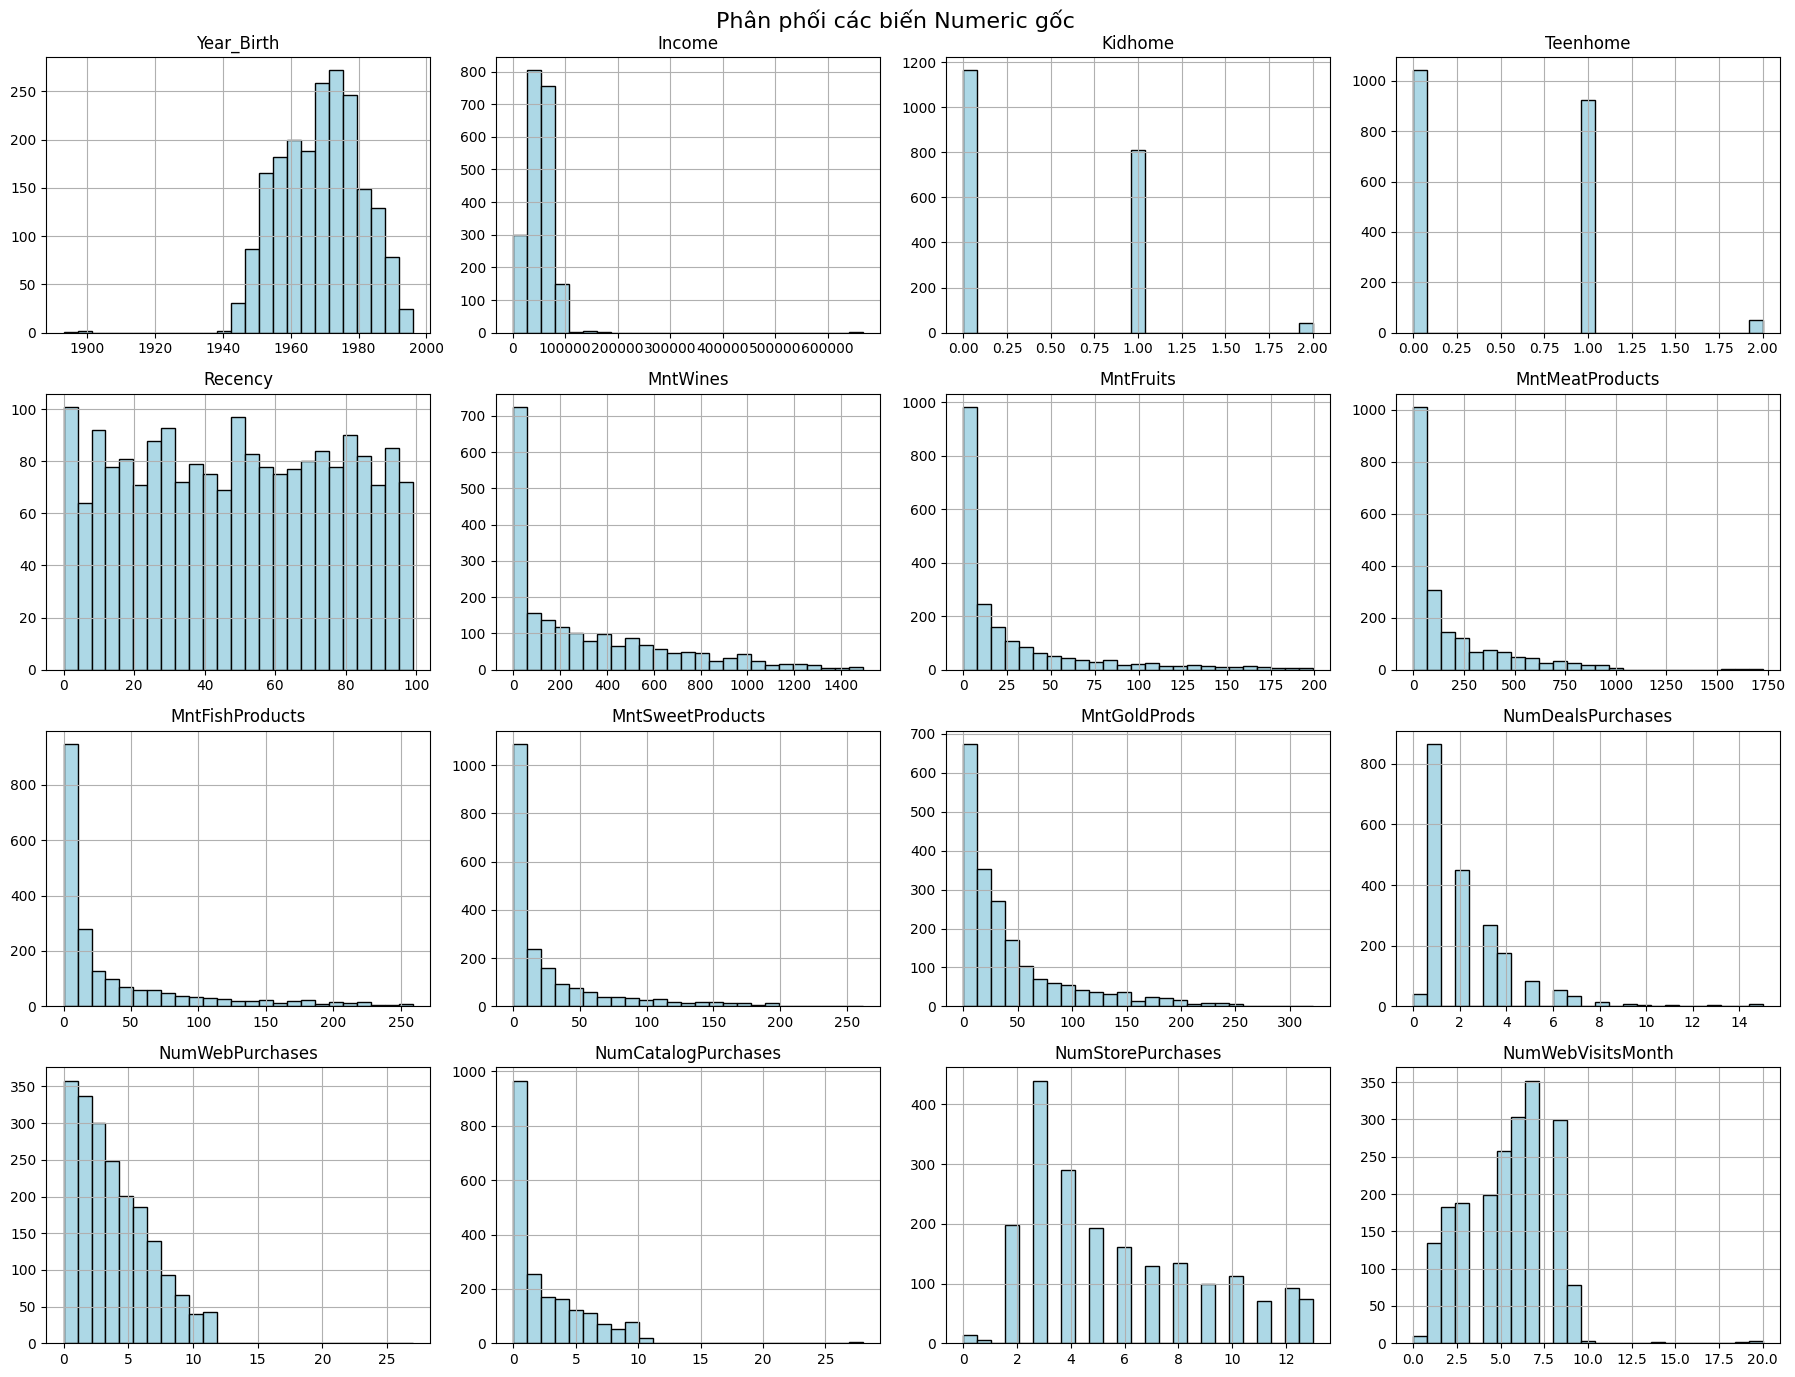

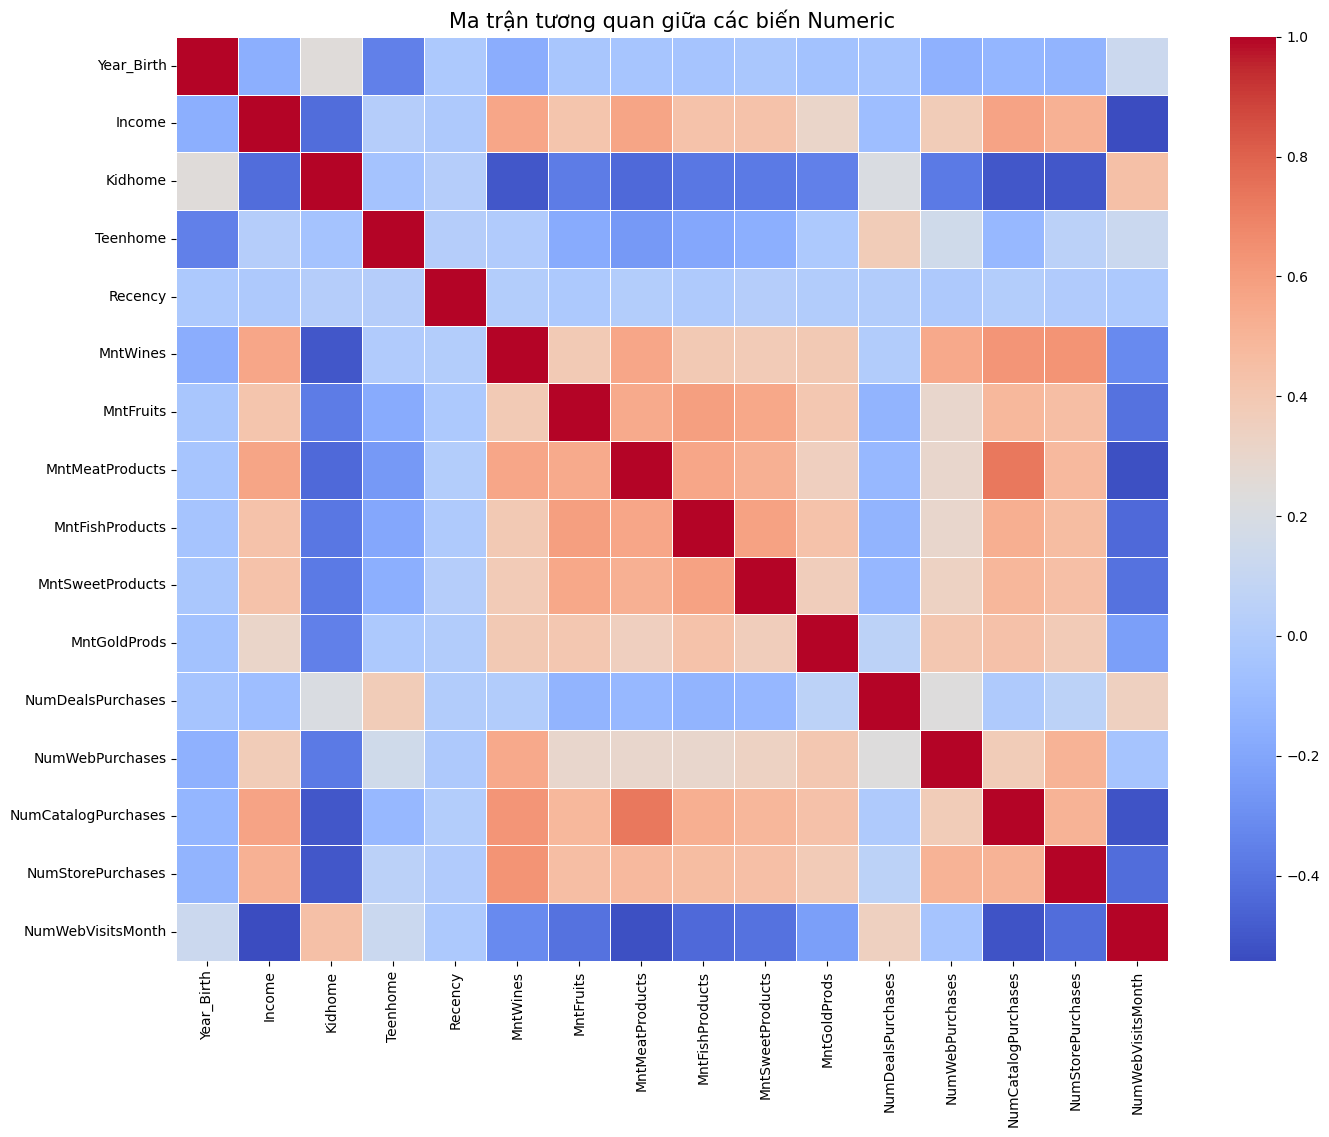

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

print("=== 2. EDA CHO BIẾN NUMERIC ===")

numeric_cols = ['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency',
                'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
                'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
                'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
                'NumWebVisitsMonth']

print(df[numeric_cols].describe().round(2))

# Histogram
df[numeric_cols].hist(bins=25, figsize=(18, 14), color='lightblue', edgecolor='black')
plt.suptitle('Phân phối các biến Numeric gốc', fontsize=16)
plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(16, 12))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Ma trận tương quan giữa các biến Numeric', fontsize=15)
plt.show()

1. Tổng quan phân phối các biến Numeric (Histogram)

- Year_Birth: Phân bố gần chuẩn, tập trung mạnh ở khoảng 1950–1985 (thế hệ Baby Boomer và Gen X).
- Income: Phân bố lệch phải mạnh. Đa số khách hàng có thu nhập dưới 100.000, một nhóm nhỏ có thu nhập rất cao.
- Kidhome & Teenhome: Phần lớn khách hàng có 0 hoặc 1 con.
- Recency: Phân bố khá đều từ 0–100 ngày → tốt cho việc phân cụm.
- MntWines & MntMeatProducts: Lệch phải rõ rệt, cho thấy sự chênh lệch lớn về mức chi tiêu.
- MntFruits, MntFishProducts, MntSweetProducts: Đa số khách hàng chi rất ít (dưới 50).
- Các biến Num*Purchases: Phần lớn khách mua ít lần, chỉ một nhóm nhỏ mua rất nhiều.

Nhận xét chung: Dữ liệu có nhiều biến lệch phải mạnh, đặc trưng của hành vi tiêu dùng khách hàng.

2. Ma trận Tương quan (Correlation Heatmap)

Các tương quan quan trọng:

* Tương quan mạnh dương:

- Income có tương quan cao với MntWines, MntMeatProducts, và tổng chi tiêu.
Các biến chi tiêu (MntWines, MntMeatProducts, MntFishProducts...) tương quan mạnh với nhau.
- Các kênh mua hàng (NumWebPurchases, NumCatalogPurchases, NumStorePurchases) tương quan với nhau.

* Tương quan âm:
- Kidhome và Teenhome có tương quan âm với hầu hết các biến chi tiêu → Khách có con thường chi tiêu ít hơn.
NumWebVisitsMonth có tương quan âm nhẹ với Income → Khách thu nhập thấp hay truy cập web nhiều hơn.
- Year_Birth có tương quan âm với Income và các biến chi tiêu → Khách trẻ thường chi tiêu ít hơn.

In [9]:
print("=== 3. ENCODE CATEGORICAL VARIABLES ===")

# ====================== XỬ LÝ EDUCATION ======================
# Gộp '2n Cycle' vào 'Master'
df['Education'] = df['Education'].replace('2n Cycle', 'Master')

# Ordinal Encoding cho Education
from sklearn.preprocessing import OrdinalEncoder

education_order = ['Basic', 'Graduation', 'Master', 'PhD']

encoder = OrdinalEncoder(categories=[education_order])
df['Education_Ordinal'] = encoder.fit_transform(df[['Education']])

print("\nEducation sau khi encode (đã gộp):")
print(df[['Education', 'Education_Ordinal']].value_counts().sort_index())

# ====================== MARITAL_STATUS ======================
# One-Hot Encoding
df = pd.get_dummies(df, columns=['Marital_Status'],
                    prefix='Marital',
                    drop_first=True)

print(f"Shape hiện tại: {df.shape}")
print("Các cột Marital mới:", [col for col in df.columns if col.startswith('Marital')])

=== 3. ENCODE CATEGORICAL VARIABLES ===

Education sau khi encode (đã gộp):
Education   Education_Ordinal
Basic       0.0                    49
Graduation  1.0                  1014
Master      2.0                   515
PhD         3.0                   437
Name: count, dtype: int64
Shape hiện tại: (2015, 26)
Các cột Marital mới: ['Marital_Alone', 'Marital_Divorced', 'Marital_Married', 'Marital_Single', 'Marital_Together', 'Marital_Widow', 'Marital_YOLO']


In [17]:
print("=== 4. CHỌN FEATURES & SCALING ===")

# Chọn tất cả numeric gốc + 2 cột đã encode
features = ['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency',
            'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
            'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
            'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
            'NumWebVisitsMonth', 'Education_Ordinal']

# Thêm tất cả cột Marital_
marital_cols = [col for col in df.columns if col.startswith('Marital')]
features.extend(marital_cols)

X = df[features].copy()

print(f"Tổng số features: {len(features)}")

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"✅ Scaling hoàn tất! Shape: {X_scaled.shape}")

=== 4. CHỌN FEATURES & SCALING ===
Tổng số features: 24
✅ Scaling hoàn tất! Shape: (2015, 24)


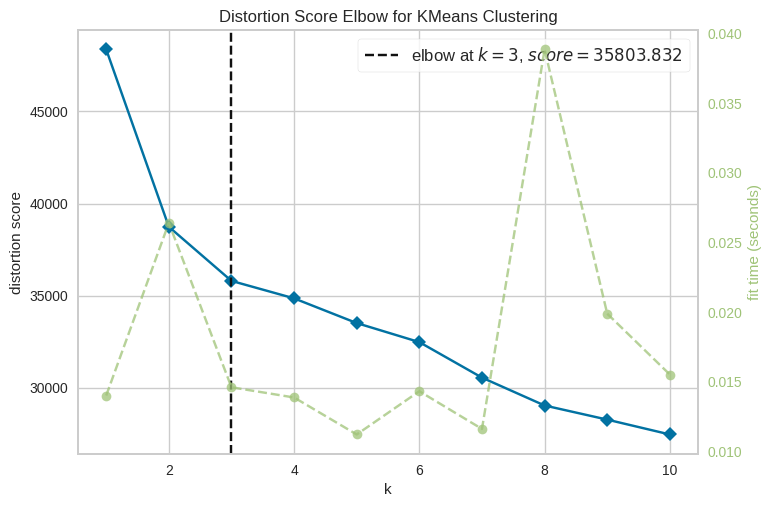

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [18]:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
elbow_method = KElbowVisualizer(KMeans(), k=(1,11))
elbow_method.fit(X_scaled)
elbow_method.show()

In [19]:
kmeans_model = KMeans(n_clusters=3)
kmeans_model.fit(X_scaled)

KMeans(n_clusters=3)

In [21]:
#để xuất ra label của tập training (scaled_data) ta dùng .labels_
kmeans_model.labels_

array([2, 0, 2, ..., 1, 1, 0], dtype=int32)

In [22]:
#để dự đoán ra label của tập testing (ta giả sử là scaled_data) ta dùng .predict
kmeans_model.predict(X_scaled)

array([2, 0, 2, ..., 1, 1, 0], dtype=int32)

In [ ]:
#Để xuất ra các centroids ta có thể dùng .cluster_centers_
kmeans_model.cluster_centers_

array([[-0.05463215,  0.96287565, -0.74701275, -0.59738957, -0.0016234 ,
         0.84348083,  1.09637252,  1.27077914,  1.14614371,  1.08902564,
         0.62783135, -0.50547086,  0.40842766,  1.13582475,  0.79037128,
        -1.00928747, -0.05753503, -0.03861416, -0.05374033, -0.06722965,
         0.08280558,  0.0157785 ,  0.04125611, -0.02228283],
       [ 0.26880784, -0.69943019,  0.70048378, -0.13662313,  0.01007511,
        -0.78866602, -0.54209306, -0.64170658, -0.56107938, -0.53663905,
        -0.55030393, -0.13977674, -0.72822929, -0.73142742, -0.81295995,
         0.48776608, -0.09584229,  0.01870262, -0.02395302, -0.01535825,
         0.06219858,  0.00747916, -0.07285383, -0.02228283],
       [-0.36789014,  0.21534967, -0.41211339,  0.7520896 , -0.01417229,
         0.4617982 , -0.14956106, -0.15258345, -0.16507873, -0.15138622,
         0.28672031,  0.67389553,  0.76124551,  0.10868297,  0.54751816,
         0.15517357,  0.20078599,  0.00587271,  0.08576095,  0.08461277,
  

##PCA

In [31]:
from sklearn.decomposition import PCA #Khai báo thư viện PCA
pca = PCA(n_components=3) #khai báo
pca.fit(X_scaled)

PCA(n_components=3)

In [32]:
#cho ta biết được các thành phần phủ được bao nhiêu lượng thông tin của data gốc
a = pca.explained_variance_ratio_ * 100

In [33]:
a

array([25.14065092,  8.46430471,  6.28928435])

##3 dimensional PCA

In [34]:
pca = PCA(n_components=3) #dùng pca 3 thành phần
pca_df = pd.DataFrame(pca.fit_transform(X_scaled), columns=["pca_1", "pca_2", "pca_3"])#tạo ra dataframe với 3 thành phàn là pca1, pca2, và pca3

In [35]:
pca_ = PCA(n_components=3)
pca_.fit(X_scaled)
pca_.explained_variance_ratio_

array([0.25140651, 0.08464305, 0.06289284])

In [36]:
pca_df

,pca_1,pca_2,pca_3
0,3.799149,-0.861656,-0.523195
1,-2.302986,-0.340449,-0.997975
2,1.882808,-0.312387,-1.256592
3,-2.474727,-1.456890,-1.043161
4,-0.303693,0.071884,1.670821
...,...,...,...
2010,5.183245,0.771181,-1.842260
2011,2.673212,1.038583,1.659869
2012,1.301821,-0.473647,-0.499022
2013,2.062774,1.183652,-1.466843


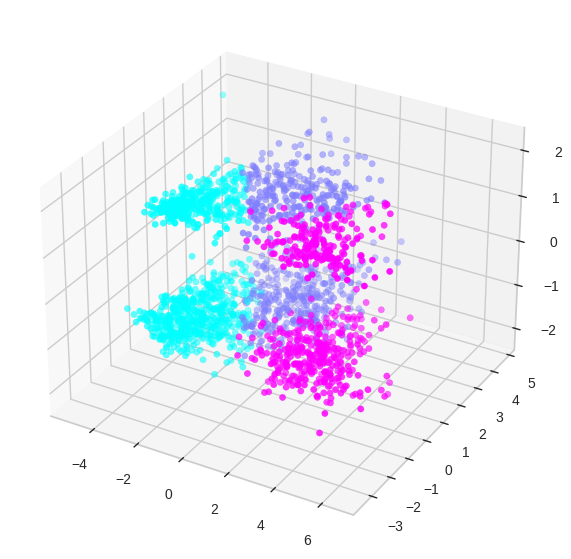

In [37]:
plt.figure(figsize=(12, 7))
ax = plt.subplot(projection="3d")
ax.scatter(pca_df.pca_1, pca_df.pca_2, pca_df.pca_3, c=kmeans_model.labels_, cmap="cool")
plt.show()

##2 dimensional PCA

In [38]:
pca = PCA(n_components=2)
pca.fit(X_scaled)
pca_df = pd.DataFrame(pca.transform(X_scaled), columns=["pca1", "pca2"])

In [39]:
pca.components_


array([[-7.14697287e-02,  2.99406631e-01, -2.74596872e-01,
        -4.54799720e-02,  2.32517197e-03,  3.05787371e-01,
         2.86028282e-01,  3.24329109e-01,  2.95806845e-01,
         2.84297036e-01,  2.35793601e-01, -4.93876991e-02,
         2.24267888e-01,  3.31232750e-01,  3.03170093e-01,
        -2.60304043e-01,  9.08460518e-03, -1.32803384e-02,
        -1.49299018e-04, -7.24530062e-03, -4.78316623e-03,
         3.61446088e-04,  2.94810527e-02, -3.69709017e-03],
       [-3.58053661e-01,  6.07407634e-02, -7.97771665e-02,
         5.23640024e-01,  1.05954036e-02,  1.81915026e-01,
        -1.49722279e-01, -1.37194209e-01, -1.58365512e-01,
        -1.28479464e-01,  6.29299322e-02,  4.26764467e-01,
         3.29284125e-01,  5.06386262e-03,  1.54677775e-01,
         1.84732776e-01,  2.21756664e-01,  2.37246683e-02,
         1.08574144e-01,  4.71160954e-02, -2.06329557e-01,
         2.15856491e-02,  9.90786536e-02,  4.81577990e-02]])

In [40]:
pca_df.head()

,pca1,pca2
0,3.799149,-0.861656
1,-2.302986,-0.340449
2,1.882808,-0.312387
3,-2.474727,-1.456890
4,-0.303693,0.071884


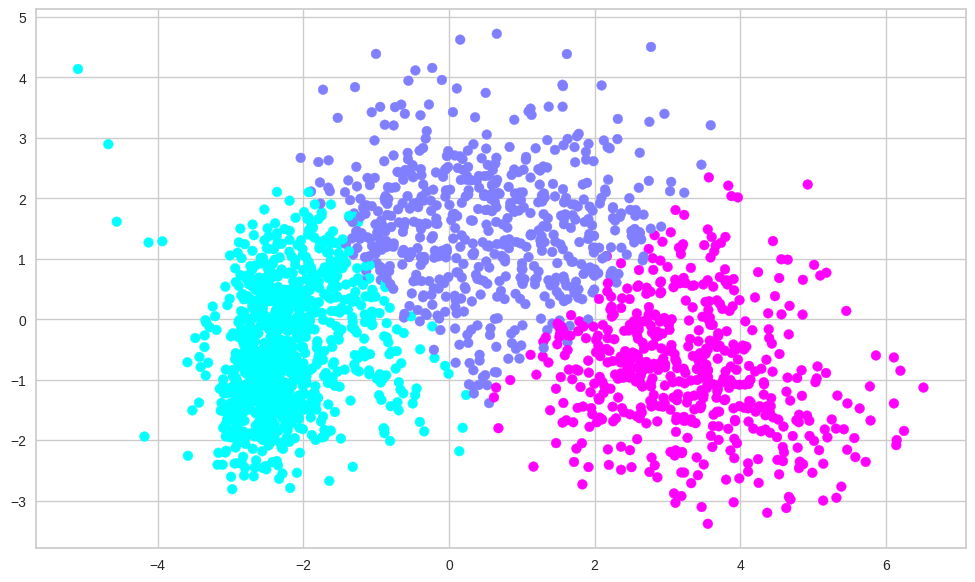

In [41]:
plt.figure(figsize=(12, 7))
ax = plt.subplot()
ax.scatter(pca_df.pca1, pca_df.pca2, c=kmeans_model.labels_, cmap="cool")
plt.show()

##Nếu muốn vẽ có thêm legend

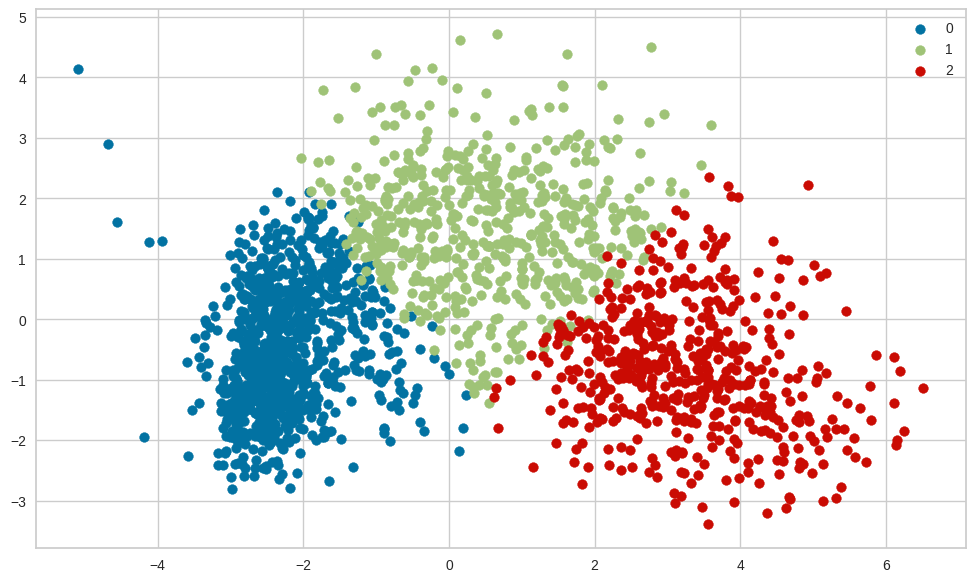

In [42]:
plt.figure(figsize=(12, 7))
ax = plt.subplot()
group = kmeans_model.labels_
for g in np.unique(group):
    index = np.where(group==g)
    ax.scatter(pca_df.iloc[index].pca1, pca_df.iloc[index].pca2, label=g, cmap="cool")
ax.legend()
plt.show()

#Save và load model

In [43]:
#Save model
import pickle #import thư viện pickle

file_name = "model.sav" #Tạo tên cũng như đường dẫn lưu model (nếu chỉ để tên model không thì sẽ lưu tại thư mục hiện hành)
pickle.dump(kmeans_model, open(file_name, "wb")) #nhận vào tên thư viện và đường dẫn lưu trữ model

file_name = "scaler.sav" #Tạo tên cũng như đường dẫn lưu model (nếu chỉ để tên model không thì sẽ lưu tại thư mục hiện hành)
pickle.dump(scaler, open(file_name, "wb")) #nhận vào tên thư viện và đường dẫn lưu trữ model

In [45]:
#Load model
file_name = "model.sav"
model = pickle.load(open(file_name, "rb"))

file_name = "scaler.sav"
scaler = pickle.load(open(file_name, "rb"))

#Lấy ra các dataframe theo cluster

In [46]:
model.labels_

array([2, 0, 2, ..., 1, 1, 0], dtype=int32)

In [47]:
cluster = model.labels_
cluster_0 = np.where(cluster==0) #index các data samples thuộc cluster 1
cluster_1 = np.where(cluster==1) #index các data samples thuộc cluster 2
cluster_2 = np.where(cluster==2) #index các data samples thuộc cluster 3

In [48]:
#Lấy ra các data samples thuộc cluster 1
df.iloc[cluster_0]

,Year_Birth,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,Age,Education_Ordinal,Marital_Alone,Marital_Divorced,Marital_Married,Marital_Single,Marital_Together,Marital_Widow,Marital_YOLO
1,1954,Graduation,46344.0,1,1,38,11,1,6,2,...,5,71,1.0,False,False,False,True,False,False,False
3,1984,Graduation,26646.0,1,0,26,11,4,20,10,...,6,41,1.0,False,False,False,False,True,False,False
7,1985,PhD,33454.0,1,0,32,76,10,56,3,...,8,40,3.0,False,False,True,False,False,False,False
8,1974,PhD,30351.0,1,0,19,14,0,24,3,...,9,51,3.0,False,False,False,False,True,False,False
9,1950,PhD,5648.0,1,1,68,28,0,6,1,...,20,75,3.0,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2002,1963,Master,33562.0,1,2,33,21,12,12,0,...,4,62,2.0,False,False,True,False,False,False,False
2006,1972,Graduation,24434.0,2,0,9,3,2,8,20,...,7,53,1.0,False,False,True,False,False,False,False
2007,1984,Graduation,11012.0,1,0,82,24,3,26,7,...,9,41,1.0,False,False,False,True,False,False,False
2009,1986,Graduation,26816.0,0,0,50,5,1,6,3,...,4,39,1.0,False,False,False,True,False,False,False
